# Libraries used


In [5]:
import os
import glob
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme()

# sklearn imports
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    HistGradientBoostingRegressor
)
from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error,
    mean_absolute_percentage_error
)
from sklearn.model_selection import (
    cross_val_score,
    TimeSeriesSplit,
    RandomizedSearchCV
)

import xgboost as xgb
from IPython.display import clear_output

In [6]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [7]:
!kaggle datasets download -d abhisheksjha/time-series-air-quality-data-of-india-2010-2023


Dataset URL: https://www.kaggle.com/datasets/abhisheksjha/time-series-air-quality-data-of-india-2010-2023
License(s): CC-BY-NC-SA-4.0
100% 464M/464M [00:03<00:00, 128MB/s]



## Loading the data


In [8]:

!unzip time-series-air-quality-data-of-india-2010-2023.zip -d air_quality_data



Archive:  time-series-air-quality-data-of-india-2010-2023.zip
  inflating: air_quality_data/AP001.csv  
  inflating: air_quality_data/AP002.csv  
  inflating: air_quality_data/AP003.csv  
  inflating: air_quality_data/AP004.csv  
  inflating: air_quality_data/AP005.csv  
  inflating: air_quality_data/AP006.csv  
  inflating: air_quality_data/AP007.csv  
  inflating: air_quality_data/AP008.csv  
  inflating: air_quality_data/AP009.csv  
  inflating: air_quality_data/AP010.csv  
  inflating: air_quality_data/AR001.csv  
  inflating: air_quality_data/AS001.csv  
  inflating: air_quality_data/AS002.csv  
  inflating: air_quality_data/AS003.csv  
  inflating: air_quality_data/AS004.csv  
  inflating: air_quality_data/AS005.csv  
  inflating: air_quality_data/AS006.csv  
  inflating: air_quality_data/AS007.csv  
  inflating: air_quality_data/AS008.csv  
  inflating: air_quality_data/AS009.csv  
  inflating: air_quality_data/BR001.csv  
  inflating: air_quality_data/BR002.csv  
  inflating: a

In [9]:
import os
os.listdir('air_quality_data')[:10]


['RJ028.csv',
 'BR007.csv',
 'BR015.csv',
 'WB001.csv',
 'RJ007.csv',
 'WB010.csv',
 'AS008.csv',
 'HR022.csv',
 'DL039.csv',
 'WB011.csv']

In [10]:
import pandas as pd

stations_df = pd.read_csv("air_quality_data/stations_info.csv")
stations_df.drop(columns=['agency', 'station_location', 'start_month'], inplace=True, errors='ignore')
stations_df.head()


,file_name,state,city,start_month_num,start_year
0,AP001,Andhra Pradesh,Tirupati,7,2016
1,AP002,Andhra Pradesh,Vijayawada,5,2017
2,AP003,Andhra Pradesh,Visakhapatnam,7,2017
3,AP004,Andhra Pradesh,Rajamahendravaram,9,2017
4,AP005,Andhra Pradesh,Amaravati,11,2017


In [11]:
import os
print("Current directory contains:", os.listdir('.'))
if os.path.exists('air_quality_data'):
    print("Contents of air_quality_data:", os.listdir('air_quality_data')[:10])

Current directory contains: ['.config', 'time-series-air-quality-data-of-india-2010-2023.zip', 'air_quality_data', 'sample_data']
Contents of air_quality_data: ['RJ028.csv', 'BR007.csv', 'BR015.csv', 'WB001.csv', 'RJ007.csv', 'WB010.csv', 'AS008.csv', 'HR022.csv', 'DL039.csv', 'WB011.csv']


In [ ]:
def process_and_merge(stations_df, raw_data_path, output_file="merged.csv"):
    import os
    import glob
    import pandas as pd
    from tqdm import tqdm

    available_files = glob.glob(f"{raw_data_path}/**/*.csv", recursive=True)
    file_map = {os.path.basename(f).replace('.csv', '').upper(): f for f in available_files}

    print(f"System Check: Found {len(file_map)} CSV files in folder.")

    first = True  

    for _, row in tqdm(stations_df.iterrows(), total=stations_df.shape[0]):
        clean_name = str(row['file_name']).replace('.csv', '').upper().strip()

        if clean_name in file_map:
            df = pd.read_csv(file_map[clean_name])
            df['city'] = row['city']
            df['state'] = row['state']
            df.columns = df.columns.str.strip()

          
            df.to_csv(output_file, mode='a', index=False, header=first)
            first = False

    print(f"\n Data merged and saved to {output_file}")


In [13]:

master_df = process_and_merge(stations_df, 'air_quality_data')

System Check: Found 454 CSV files in folder.


100%|██████████| 453/453 [04:25<00:00,  1.71it/s]


 Data merged and saved to merged.csv


In [ ]:
import numpy as np
import pandas as pd

def inject_advanced_health_data(df):
    # 1. clean and normalize
    df.columns = df.columns.str.strip().str.lower()

    # Handle both common versions of PM2.5 naming
    df.rename(columns={
        'pm2.5 (ug/m3)': 'pm2_5',
        'pm2.5': 'pm2_5',
        'pm10 (ug/m3)': 'pm10',
        'no2 (ug/m3)': 'no2',
        'ozone (ug/m3)': 'ozone'
    }, inplace=True, errors='ignore')

  
    required_cols = ['pm2_5', 'pm10', 'no2', 'ozone']
    for col in required_cols:
        if col not in df.columns:
            df[col] = 0

    n = len(df)

    # 2. personal Factors
    df['age'] = np.random.randint(5, 85, size=n)
    df['is_smoker'] = np.random.choice([0, 1], size=n, p=[0.8, 0.2])
    df['has_asthma'] = np.random.choice([0, 1], size=n, p=[0.9, 0.1])

    # 3. mask
    # 0: None, 1: Cloth, 2: Surgical, 3: N95
    df['mask_type'] = np.random.choice([0, 1, 2, 3], size=n, p=[0.7, 0.15, 0.1, 0.05])

    # protection map
    # N95 filters 95%; No mask is 1.0 (100% passes)
    protection_map = {0: 1.0, 1: 0.7, 2: 0.4, 3: 0.05}
    exposure_multiplier = df['mask_type'].map(protection_map)

    # 4. env risk
    #  PM2.5 and PM10 are particles, so masks filter them heavily.
    # Gases like NO2/Ozone are less filtered by basic masks, we apply the multiplier to show the benefit of high-end masks.
    pm_risk = (df['pm2_5'] * 0.5 + df['pm10'] * 0.2) * exposure_multiplier
    gas_risk = (df['no2'] * 0.2 + df['ozone'] * 0.1) # Gases have constant impact

    env_risk = (pm_risk + gas_risk) / 300.0

    # 5. personal vulnerability
    vulnerability = 1.0
    vulnerability += (df['is_smoker'] * 0.3)
    vulnerability += (df['has_asthma'] * 0.4)
    vulnerability += ((df['age'] > 60).astype(int) * 0.2)

    # final risk
    df['health_risk_score'] = (env_risk * vulnerability).clip(0, 1)

    return df

In [18]:
cols = pd.read_csv("merged.csv", nrows=0).columns.tolist()
print(cols)


['From Date', 'To Date', 'PM2.5 (ug/m3)', 'PM10 (ug/m3)', 'NO (ug/m3)', 'NO2 (ug/m3)', 'NOx (ppb)', 'NH3 (ug/m3)', 'SO2 (ug/m3)', 'CO (mg/m3)', 'Ozone (ug/m3)', 'Benzene (ug/m3)', 'Toluene (ug/m3)', 'Temp (degree C)', 'RH (%)', 'WS (m/s)', 'WD (deg)', 'SR (W/mt2)', 'BP (mmHg)', 'VWS (m/s)', 'Xylene (ug/m3)', 'RF (mm)', 'AT (degree C)', 'city', 'state']


In [16]:
pip install pyarrow fastparquet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 33.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import csv

def optimized_injection(input_file, output_file):
    chunk_size = 50000
    first = True

    # fault-tolerant reader for large files
    reader = pd.read_csv(
        input_file,
        chunksize=chunk_size,
        low_memory=False,
        on_bad_lines='skip',
        quoting=csv.QUOTE_MINIMAL
    )

    print("Starting Fault-Tolerant Optimized Injection with Mask Logic...")

    for i, chunk in enumerate(reader):
        try:
            # 1. clean and normalize
            chunk.columns = chunk.columns.str.split('(').str[0].str.strip().str.lower().str.replace('.', '_', regex=False)

            # 2. identify available pollutants
            # This ensures we don't crash if a city is missing a specific sensor
            pollutant_map = {'pm2_5': 0.5, 'pm10': 0.2, 'no2': 0.2, 'ozone': 0.1}
            available_pollutants = [p for p in pollutant_map.keys() if p in chunk.columns]

            # 3. type casting
            for col in available_pollutants:
                chunk[col] = pd.to_numeric(chunk[col], errors='coerce').fillna(0).astype(np.float32)

           
            n = len(chunk)
            chunk['age'] = np.random.randint(5, 85, size=n).astype(np.int8)
            chunk['is_smoker'] = np.random.choice([0, 1], size=n, p=[0.8, 0.2]).astype(np.int8)
            chunk['has_asthma'] = np.random.choice([0, 1], size=n, p=[0.9, 0.1]).astype(np.int8)

           
            chunk['mask_type'] = np.random.choice([0, 1, 2, 3], size=n, p=[0.7, 0.15, 0.1, 0.05]).astype(np.int8)

           
            protection_map = {0: 1.0, 1: 0.7, 2: 0.4, 3: 0.05}
            exposure_multiplier = chunk['mask_type'].map(protection_map)

            pm_risk = (chunk.get('pm2_5', 0) * 0.5 + chunk.get('pm10', 0) * 0.2) * exposure_multiplier
            gas_risk = (chunk.get('no2', 0) * 0.2 + chunk.get('ozone', 0) * 0.1)

            env_risk = (pm_risk + gas_risk) / 300.0

            vulnerability = 1.0 + (chunk['is_smoker'] * 0.3) + (chunk['has_asthma'] * 0.4) + ((chunk['age'] > 60).astype(int) * 0.2)

            chunk['health_risk_score'] = (env_risk * vulnerability).clip(0, 1).astype(np.float32)

            chunk.to_csv(output_file, mode='a', index=False, header=first)

            if i % 10 == 0:
                print(f"Processed chunk {i} ({i * chunk_size} rows)...")
            first = False

        except Exception as e:
            print(f"Skipped a broken chunk at index {i} due to: {e}")
            continue

    print("--- INJECTION COMPLETE ---")


optimized_injection("merged.csv", "final_with_health_v2.csv")

Starting Fault-Tolerant Optimized Injection with Mask Logic...
Processed chunk 0 (0 rows)...
Processed chunk 10 (500000 rows)...
Processed chunk 20 (1000000 rows)...
Processed chunk 30 (1500000 rows)...
Processed chunk 40 (2000000 rows)...
Processed chunk 50 (2500000 rows)...
Processed chunk 60 (3000000 rows)...
Processed chunk 70 (3500000 rows)...
Processed chunk 80 (4000000 rows)...
Processed chunk 90 (4500000 rows)...
Processed chunk 100 (5000000 rows)...
Processed chunk 110 (5500000 rows)...
Processed chunk 120 (6000000 rows)...
Processed chunk 130 (6500000 rows)...
Processed chunk 140 (7000000 rows)...
Processed chunk 150 (7500000 rows)...
Processed chunk 160 (8000000 rows)...
Processed chunk 170 (8500000 rows)...
Processed chunk 180 (9000000 rows)...
--- INJECTION COMPLETE ---


In [ ]:
import pandas as pd
import os


def create_smart_sample_in_colab(input_path, output_path):
    print("Running Smart Sampling on Colab VM...")

    chunks = pd.read_csv(input_path, chunksize=100000, low_memory=False)

    sample_list = []
    for chunk in chunks:
        # taking 2.5% of each chunk 
        sample_list.append(chunk.sample(frac=0.025))

    df_sample = pd.concat(sample_list)

   
    df_sample.to_csv(output_path, index=False)
    print(f"Sample created: {len(df_sample)} rows.")
    print(f"File size reduced from 1.8GB to approx {os.path.getsize(output_path) / (1024*1024):.2f} MB")


create_smart_sample_in_colab('final_with_health_v2.csv', 'colab_train_ready.csv')

Running Smart Sampling on Colab VM...
Sample created: 236874 rows.
File size reduced from 1.8GB to approx 36.20 MB


# Generation



In [3]:
!pip install sdv
import pandas as pd
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 kB 8.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 16.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.7/14.7 MB 115.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 74.5/74.5 kB 9.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.3/202.3 kB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 100.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 11.6 MB/s eta 0:00:00


# User Profile

In [23]:
import pandas as pd
import numpy as np

#loading
df = pd.read_csv("colab_train_ready.csv", low_memory=False)

# 2. normalize
df.columns = df.columns.str.split('(').str[0].str.strip().str.lower().str.replace('.', '_', regex=False)

# 3. masking
def apply_final_logic(df):
    n = len(df)
    df['mask_type'] = np.random.choice([0, 1, 2, 3], size=n, p=[0.7, 0.15, 0.1, 0.05])
    protection = {0: 1.0, 1: 0.7, 2: 0.4, 3: 0.05}

    # cleaned
    pm25_clean = pd.to_numeric(df['pm2_5'], errors='coerce').fillna(0)
    no2_clean = pd.to_numeric(df['no2'], errors='coerce').fillna(0)
    ozone_clean = pd.to_numeric(df['ozone'], errors='coerce').fillna(0)

    env_risk = (pm25_clean * df['mask_type'].map(protection) * 0.5 + no2_clean * 0.3 + ozone_clean * 0.2) / 300.0
    vulnerability = 1.0 + (df['is_smoker'] * 0.3) + (df['has_asthma'] * 0.4)
    df['health_risk_score'] = (env_risk * vulnerability).clip(0, 1).astype(np.float32)
    return df

train_data = apply_final_logic(df)

print("Check: 'train_data' is created with columns:", train_data.columns.tolist())

Check: 'train_data' is created with columns: ['from date', 'to date', 'pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone', 'benzene', 'toluene', 'temp', 'rh', 'ws', 'wd', 'sr', 'bp', 'vws', 'xylene', 'rf', 'at', 'city', 'state', 'age', 'is_smoker', 'has_asthma', 'mask_type', 'health_risk_score']


In [ ]:
from sdv.metadata import Metadata
from sdv.single_table import CTGANSynthesizer

# create Metadata
metadata = Metadata.detect_from_dataframe(train_data)

# stops CTGAN from creating thousands of dummy columns
numerical_cols = ['pm2_5', 'pm10', 'no2', 'so2', 'co', 'ozone', 'temp', 'rh', 'age', 'health_risk_score']

for col in numerical_cols:
    metadata.update_column(column_name=col, sdtype='numerical')

categorical_cols = ['is_smoker', 'has_asthma', 'mask_type']
for col in categorical_cols:
    metadata.update_column(column_name=col, sdtype='categorical')

print("Metadata Fixed! Numerical columns are now treated as continuous ranges.")

Metadata Fixed! Numerical columns are now treated as continuous ranges.


In [ ]:
cols_to_round = ['so2', 'co', 'temp', 'rh']
train_data[cols_to_round] = train_data[cols_to_round].round(2)

In [ ]:
numerical_cols = ['pm2_5', 'pm10', 'no2', 'so2', 'co', 'ozone', 'temp', 'rh', 'age', 'health_risk_score']


for col in numerical_cols:
    train_data[col] = pd.to_numeric(train_data[col], errors='coerce')

train_data[numerical_cols] = train_data[numerical_cols].fillna(0.0)
print(train_data[numerical_cols].dtypes)

pm2_5                float64
pm10                 float64
no2                  float64
so2                  float64
co                   float64
ozone                float64
temp                 float64
rh                   float64
age                    int64
health_risk_score    float32
dtype: object


In [ ]:
from sdv.metadata import Metadata

metadata = Metadata.detect_from_dataframe(train_data)

categorical_cols = ['is_smoker', 'has_asthma', 'mask_type']
for col in categorical_cols:
    metadata.update_column(column_name=col, sdtype='categorical')

print("Metadata verified and matched to cleaned numerical data.")

Metadata verified and matched to cleaned numerical data.


In [ ]:
from sdv.metadata import Metadata

# 1. drop non-numeric columns
train_data = train_data.drop(columns=['from date', 'to date'], errors='ignore')

# 2. detect fresh
metadata = Metadata.detect_from_dataframe(train_data)

# 3. force all to numerical
all_numeric = [
    'pm2_5', 'pm10', 'no', 'no2', 'nox', 'nh3', 'so2', 'co', 'ozone',
    'benzene', 'toluene', 'temp', 'rh', 'ws', 'wd', 'sr', 'bp',
    'vws', 'xylene', 'rf', 'at', 'age', 'health_risk_score'
]

for col in all_numeric:
    if col in train_data.columns:
        train_data[col] = pd.to_numeric(train_data[col], errors='coerce').fillna(0)
        metadata.update_column(column_name=col, sdtype='numerical')

# 4. set categories
for col in ['is_smoker', 'has_asthma', 'mask_type']:
    if col in train_data.columns:
        metadata.update_column(column_name=col, sdtype='categorical')

print("Metadata and Data synchronized.")

Metadata and Data synchronized.


In [34]:
from google.colab import drive
drive.mount('/content/drive')

metadata.save_to_json('/content/drive/MyDrive/metadata.json')
synthesizer.save('/content/drive/MyDrive/ctgan_model.pkl')


Mounted at /content/drive


# Training the **CTGAN**

In [33]:
from sdv.single_table import CTGANSynthesizer

# 1. init
synthesizer = CTGANSynthesizer(
    metadata,
    enforce_min_max_values=True,
    epochs=100,
    verbose=True
)

# 2. fit
print("Starting GAN training...")
synthesizer.fit(train_data)

# 3. save
synthesizer.save('breathesafe_v2_generator.pkl')

/usr/local/lib/python3.12/dist-packages/sdv/single_table/base.py:134: UserWarning: We strongly recommend saving the metadata using 'save_to_json' for replicability in future SDV versions.
  warnings.warn(


Starting GAN training...


Gen. (-00.89) | Discrim. (+00.01): 100%|██████████| 100/100 [36:08<00:00, 21.69s/it]


In [4]:
import joblib

# 1. save gan
synthesizer.save('breathesafe_v2_generator.pkl')

# 2. save metadata
metadata.save_to_json('breathesafe_metadata.json')

# 3. generate and save data
synthetic_df = synthesizer.sample(num_rows=200000)
synthetic_df.to_csv('final_gen_ai_data.csv', index=False)

print("All files saved to Colab disk.")

NameError: name 'synthesizer' is not defined

In [ ]:
from google.colab import files

# download the critical files
files.download('breathesafe_v2_generator.pkl')
files.download('breathesafe_metadata.json')
files.download('final_gen_ai_data.csv')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloads started. Keep these safe for your GitHub and App.


In [38]:
# 1. sample
print("Generating synthetic master dataset...")
synthetic_df = synthesizer.sample(num_rows=200000)

# 2. logical audit (no 5-year-old smokers)
synthetic_df.loc[synthetic_df['age'] < 18, 'is_smoker'] = 0

# 3. save
synthetic_df.to_csv('final_gen_ai_data.csv', index=False)
print("Master dataset saved.")

Generating synthetic master dataset...
Master dataset saved.


In [ ]:
import xgboost as xgb
import joblib
from sklearn.model_selection import train_test_split


cols_to_drop = ['city', 'state', 'health_risk_score']
X = synthetic_df.drop(columns=[c for c in cols_to_drop if c in synthetic_df.columns])
y = synthetic_df['health_risk_score']


cat_cols = ['is_smoker', 'has_asthma', 'mask_type']
for col in cat_cols:
    if col in X.columns:
        X[col] = X[col].astype('category')


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training final XGBoost model...")
model = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    enable_categorical=True,
    tree_method="hist" 
)

model.fit(X_train, y_train)


joblib.dump(model, 'breathesafe_model.pkl')
print("Success! Model saved as breathesafe_model.pkl")

NameError: name 'synthetic_df' is not defined

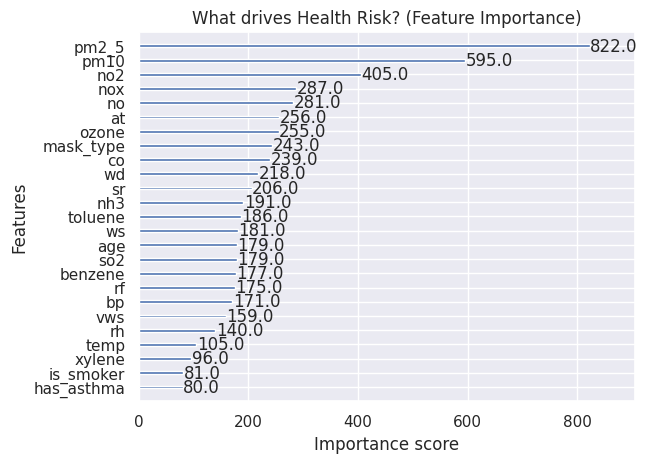

In [ ]:
import matplotlib.pyplot as plt

# plot which features the model cares about most
xgb.plot_importance(model)
plt.title("What drives Health Risk? (Feature Importance)")
plt.show()

## download


In [ ]:
from google.colab import files


files.download('breathesafe_model.pkl')
files.download('final_gen_ai_data.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Evaluation

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error
import numpy as np


y_pred = model.predict(X_test)


mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"--- Model Evaluation Report ---")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R2 Score (Accuracy of Logic): {r2:.4f}")

NameError: name 'model' is not defined

# Catboost

In [46]:
!pip install catboost


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.3 MB/s eta 0:00:00


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from catboost import CatBoostRegressor
import joblib


df = pd.read_csv('final_gen_ai_data.csv')



In [ ]:
from catboost import CatBoostRegressor
import joblib


cat_cols = ['is_smoker', 'has_asthma', 'mask_type']


cat_model = CatBoostRegressor(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE',
    silent=True,
    allow_writing_files=False
)

print("Training final CatBoost model with cat_features...")
cat_model.fit(X_train, y_train, cat_features=cat_cols)

joblib.dump(cat_model, 'catboost_model.pkl')
print("Success! CatBoost saved.")

Training final CatBoost model with cat_features...
Success! CatBoost saved.


# Ensemble

In [16]:
from sklearn.ensemble import VotingRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor
import joblib


cat_cols = ['is_smoker', 'has_asthma', 'mask_type']

# re-init XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    enable_categorical=True,
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)


print("Training CatBoost expert...")
cat_model = CatBoostRegressor(
    iterations=100,
    depth=6,
    learning_rate=0.1,
    loss_function='RMSE',
    silent=True,
    allow_writing_files=False
)
cat_model.fit(X_train, y_train, cat_features=cat_cols)





Training CatBoost expert...


CatBoostRegressor(allow_writing_files=False, depth=6, iterations=100, learning_rate=0.1, loss_function='RMSE', silent=True)

In [ ]:
ensemble = VotingRegressor(estimators=[
    ('xgb', xgb_model),
    ('cat', cat_model)
])

ensemble.estimators_ = [xgb_model, cat_model]
ensemble.le_ = None 
ensemble.fitted_ = True

joblib.dump(ensemble, 'breathesafe_ensemble.pkl')
print("Success! Master Ensemble saved as breathesafe_ensemble.pkl")

Success! Master Ensemble saved as breathesafe_ensemble.pkl


# Final evaluation

In [ ]:
import numpy as np
from sklearn.metrics import mean_absolute_error, r2_score


y_pred = ensemble.predict(X_test)


print(f"Ensemble MAE: {mean_absolute_error(y_test, y_pred):.4f}")
print(f"Ensemble R2: {r2_score(y_test, y_pred):.4f}")

#shap 
import shap
explainer = shap.TreeExplainer(xgb_model)
joblib.dump(explainer, 'shap_explainer.pkl')


from google.colab import files
files.download('breathesafe_ensemble.pkl')
files.download('shap_explainer.pkl')

Ensemble MAE: 0.0458
Ensemble R2: 0.6539


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>